### Imports

In [1]:

%pip install pandas bs4 requests
from bs4 import BeautifulSoup
import requests
import pandas as pd 

Defaulting to user installation because normal site-packages is not writeable
  Using cached bs4-0.0.2-py2.py3-none-any.whl.metadata (411 bytes)
  Using cached requests-2.31.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached beautifulsoup4-4.12.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached charset_normalizer-3.3.2-cp312-cp312-win_amd64.whl.metadata (34 kB)
  Using cached idna-3.7-py3-none-any.whl.metadata (9.9 kB)
  Using cached urllib3-2.2.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached certifi-2024.2.2-py3-none-any.whl.metadata (2.2 kB)
  Using cached soupsieve-2.5-py3-none-any.whl.metadata (4.7 kB)
Using cached bs4-0.0.2-py2.py3-none-any.whl (1.2 kB)
Using cached requests-2.31.0-py3-none-any.whl (62 kB)
Using cached certifi-2024.2.2-py3-none-any.whl (163 kB)
Using cached charset_normalizer-3.3.2-cp312-cp312-win_amd64.whl (100 kB)
Using cached idna-3.7-py3-none-any.whl (66 kB)
Using cached urllib3-2.2.1-py3-none-any.whl (121 kB)
Using cached beautifulsoup4-4.12.3-py3-none-

### HTTP Request

#### store website in variable

In [2]:
website = 'https://www.cars.com/shopping/results/?dealer_id=&keyword=&list_price_max=&list_price_min=&maximum_distance=20&monthly_payment=&page_size=20&sort=best_match_desc&stock_type=cpo&year_max=&year_min=&zip='

#### Get Request

In [3]:
response = requests.get(website)

#### Status Code

In [4]:
response.status_code

200

### Soup Object

In [5]:
soup = BeautifulSoup(response.content, 'html.parser')

### Results

In [6]:
results = soup.find_all('div', {'class' : 'vehicle-card'})

In [7]:
len(results)

21

In [8]:
results[0]

<div class="vehicle-card inventory-ad" data-inventory-ad="true" data-koddi-click-tracking-url="https://cars.koddi.io/event-collection/beacon?action=click&amp;trackingData={trackingData}&amp;rank={rank}&amp;clientName=Cars&amp;beaconIssued=2024-05-06T17:36:38Z" data-koddi-deeplink-params="sd_campaign=inventorysearchads&amp;sd_digadprov=dealerinspire&amp;sd_channel=search&amp;ad_campaign_type=cars.com&amp;sd_program=tier3&amp;sd_adid=creative&amp;sd_digadcid=campaignid&amp;sd_keyword=keyword&amp;sd_adgroup=00-ALL-NA_PCH_inmarket_mixedsales&amp;utm_campaign=cars.com_inventory_ads&amp;utm_medium=cpc&amp;utm_source=cars.com" data-koddi-impression-tracking-url="https://cars.koddi.io/event-collection/beacon?action=impression&amp;trackingData={trackingData}&amp;rank={rank}&amp;ts={ts}&amp;clientName=Cars&amp;beaconIssued=2024-05-06T17:36:38Z" data-koddi-listing-id="2674ca09-3528-46c2-8dc0-31cfcddd5b7b" data-koddi-response='{"details":"","listing_id":"2674ca09-3528-46c2-8dc0-31cfcddd5b7b","clic

# Target necessary data
Name

Mileage

Dealer Name

Rating

Rating Count

Price

#### Name

In [9]:
results[0].find('h2').get_text()

'2020 GMC Sierra 2500 Denali'

#### Mileage

In [10]:
results[0].find('div', {'class':'mileage'}).get_text()

'23,249 mi.'

#### Dealer Name

In [11]:
results[0].find('div', {'class':'dealer-name'}).get_text().strip()

'Mitch Smith Chevrolet'

#### Rating

In [12]:
results[0].find('span', {'class':'sds-rating__count'}).get_text()

'4.1'

#### Review Count

In [13]:
results[0].find('span', {'class':'sds-rating__link'}).get_text()

'(135 reviews)'

#### Price

In [14]:
results[0].find('span', {'class':'primary-price'}).get_text()

'$68,993'

### Creating a For-Loop for all data

In [15]:
name = []
mileage = []
dealer_name = []
rating = []
review_count = []
price = []

for result in results:
    
    # name
    try:
        name.append(result.find('h2').get_text()) 
    except:
        name.append('n/a')
    
    # mileage
    try:
        mileage.append(result.find('div', {'class':'mileage'}).get_text())
    except:
        mileage.append('n/a')
    
    # dealer_name
    try:
        dealer_name.append(result.find('div', {'class':'dealer-name'}).get_text().strip())
    except:
        dealer_name.append('n/a')
        
    # rating
    try:
        rating.append(result.find('span', {'class':'sds-rating__count'}).get_text())
    except:
        rating.append('n/a')
    
    # review_count
    try:
        review_count.append(result.find('span', {'class':'sds-rating__link'}).get_text())
    except:
        review_count.append('n/a')
    
    #price 
    try:
        price.append(result.find('span', {'class':'primary-price'}).get_text())
    except:
        price.append('n/a')

### Create dic for Dataframe

In [16]:
scraped_data = pd.DataFrame({'Name': name, 'Mileage':mileage, 'Dealer_Name':dealer_name,
                                'Rating': rating, 'Review Count': review_count, 'Price ($)': price})

In [17]:
scraped_data

,Name,Mileage,Dealer_Name,Rating,Review Count,Price ($)
0,2020 GMC Sierra 2500 Denali,"23,249 mi.",Mitch Smith Chevrolet,4.1,(135 reviews),"$68,993"
1,2015 Ferrari California T,"7,478 mi.",Ferrari Maserati Alfa Romeo of Fort Lauderdale,4.8,"(2,660 reviews)","$159,900"
2,2020 Honda Civic Si Base,"14,864 mi.",Gwinnett Place Honda,4.8,"(3,636 reviews)","$30,488"
3,2021 BMW X5 PHEV xDrive45e,"22,255 mi.",BMW of Las Vegas,4.8,"(2,634 reviews)","$47,882"
4,2022 Ferrari Portofino M Base,"1,959 mi.",Twin Cities Performance,n/a,(0 reviews),"$297,990"
5,2022 Mercedes-Benz EQS 580 Base 4MATIC,"6,558 mi.",Mercedes-Benz of Salt Lake City,4.6,(427 reviews),"$75,799"
6,2021 INFINITI Q60 3.0t Red Sport 400,"27,086 mi.",INFINITI of Lexington,4.7,(61 reviews),"$40,974"
7,2023 Porsche Taycan Base,"7,025 mi.",Capital Volkswagen Volvo Porsche,4.9,"(1,713 reviews)","$112,390"
8,2021 Audi A8 L 55,"34,874 mi.",Audi Richfield,4.3,(13 reviews),"$59,950"
9,2023 Rolls-Royce Cullinan Cullinan,"3,651 mi.",Desert European Motorcars,4.8,(298 reviews),"$395,495"


# Scrapping from many pages
(Pagination)


In [18]:
name = []
mileage = []
dealer_name = []
rating = []
review_count = []
price = []

for i in range (1,12):
    
    # website in variable
  #  website = 'https://www.cars.com/shopping/results/?page='+ str(i) +'&page_size=20&dealer_id=&list_price_max=&list_price_min=&makes[]=mercedes_benz&maximum_distance=20&mileage_max=&sort=best_match_desc&stock_type=cpo&year_max=&year_min=&zip=' 
    website = 'https://www.cars.com/shopping/results/?dealer_id=&keyword=&list_price_max=&list_price_min=&maximum_distance=20&monthly_payment=&page_size=20&sort=best_match_desc&stock_type=cpo&year_max=&year_min=&zip='    
    # request to website
    response = requests.get(website)
    
    # soup object
    soup = BeautifulSoup(response.content, 'html.parser')
    
    # results
    results = soup.find_all('div', {'class' : 'vehicle-card'})
    
    # loop through results
    for result in results:
    
        # name
        try:
            name.append(result.find('h2').get_text()) 
        except:
            name.append('n/a')

        # mileage
        try:
            mileage.append(result.find('div', {'class':'mileage'}).get_text())
        except:
            mileage.append('n/a')

        # dealer_name
        try:
            dealer_name.append(result.find('div', {'class':'dealer-name'}).get_text().strip())
        except:
            dealer_name.append('n/a')

        # rating
        try:
            rating.append(result.find('span', {'class':'sds-rating__count'}).get_text())
        except:
            rating.append('n/a')

        # review_count
        try:
            review_count.append(result.find('span', {'class':'sds-rating__link'}).get_text())
        except:
            review_count.append('n/a')

        #price 
        try:
            price.append(result.find('span', {'class':'primary-price'}).get_text())
        except:
            price.append('n/a')

In [19]:
# dictionary
scraped_data = pd.DataFrame({'Name': name, 'Mileage':mileage, 'Dealer_Name':dealer_name,
                                'Rating': rating, 'Review Count': review_count, 'Price ($)': price})

In [20]:
scraped_data

,Name,Mileage,Dealer_Name,Rating,Review Count,Price ($)
0,2020 GMC Sierra 2500 Denali,"23,249 mi.",Mitch Smith Chevrolet,4.1,(135 reviews),"$68,993"
1,2021 BMW X5 PHEV xDrive45e,"22,255 mi.",BMW of Las Vegas,4.8,"(2,634 reviews)","$47,882"
2,2022 Ferrari Portofino M Base,"1,959 mi.",Twin Cities Performance,n/a,(0 reviews),"$297,990"
3,2015 Ferrari California T,"7,478 mi.",Ferrari Maserati Alfa Romeo of Fort Lauderdale,4.8,"(2,660 reviews)","$159,900"
4,2022 Mercedes-Benz EQS 580 Base 4MATIC,"6,558 mi.",Mercedes-Benz of Salt Lake City,4.6,(427 reviews),"$75,799"
...,...,...,...,...,...,...
226,2023 Mercedes-Benz AMG GT 53 AMG GT 53,"4,164 mi.",Isringhausen Imports,5.0,(977 reviews),"$104,900"
227,2023 Audi S4 Prestige-CERTIFIED,"8,548 mi.",Audi McKinney,n/a,(6 reviews),"$51,991"
228,2023 Honda Pilot 2WD EX-L 7 Passenger,"10,296 mi.",Yuma Honda,4.9,(592 reviews),"$37,998"
229,2023 Mercedes-Benz AMG E 53 E 53 AMG,"2,435 mi.",Loeber Motors Mercedes-Benz,n/a,n/a,"$66,998"


### Output to csv file

In [21]:
scraped_data.to_csv('../data/processed/scraped_data.csv', index=False)


# Cleaning

In [22]:

# Remove non-numeric characters from 'Mileage' , 'Price ($)' and 'Review Count' columns and convert them to numeric in the same datatype of old data columns
scraped_data['Mileage']=scraped_data['Mileage'].str.replace(' mi.', '').str.replace(',', '').astype(int)
scraped_data['Price ($)'] = scraped_data['Price ($)'].str.replace('$', '').str.replace(',', '').astype('int64')

# Extract numeric part from 'Review Count', remove missing values, and convert to integer
scraped_data['Review Count'] = scraped_data['Review Count'].str.extract(r'(\d+)').fillna(0).astype(int)


In [23]:
scraped_data[['Mileage','Price ($)','Review Count']]
 

,Mileage,Price ($),Review Count
0,23249,68993,135
1,22255,47882,2
2,1959,297990,0
3,7478,159900,2
4,6558,75799,427
...,...,...,...
226,4164,104900,977
227,8548,51991,6
228,10296,37998,592
229,2435,66998,0


### Searching for null values or outliers

In [24]:
scraped_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Name          231 non-null    object
 1   Mileage       231 non-null    int32 
 2   Dealer_Name   231 non-null    object
 3   Rating        231 non-null    object
 4   Review Count  231 non-null    int32 
 5   Price ($)     231 non-null    int64 
dtypes: int32(2), int64(1), object(3)
memory usage: 9.2+ KB


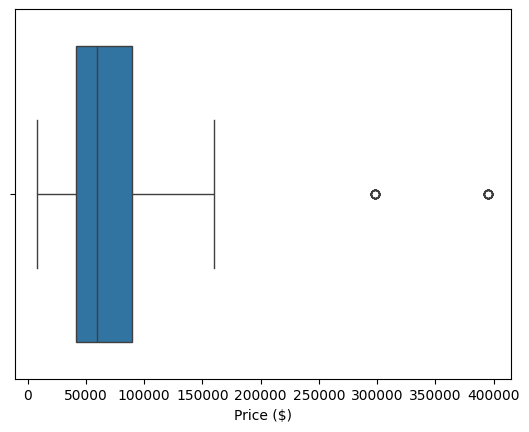

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.boxplot(x="Price ($)", data=scraped_data)
plt.show()


In [26]:
# let's detect outliers:
Q1 = scraped_data["Price ($)"].quantile(0.25)
print('Q1: ',Q1)
Q3 = scraped_data["Price ($)"].quantile(0.75)
print('Q3: ',Q3)
IQR = Q3 - Q1
print('IQR: ',IQR)

lower_bound = (1.5 * IQR) - Q1
print('lower_bound: ',lower_bound)
upper_bound = Q3 +(1.5 * IQR)
print('upper_bound: ',upper_bound)

filter_lower_bound = (scraped_data["Price ($)"] < lower_bound)
filter_upper_bound = (scraped_data["Price ($)"] > upper_bound)
# to see outliers
print(scraped_data["Price ($)"][(filter_lower_bound | filter_upper_bound)])

scraped_data["Price ($)"]=np.where(scraped_data["Price ($)"]>upper_bound,upper_bound,np.where(scraped_data["Price ($)"]<lower_bound,lower_bound,scraped_data["Price ($)"]))

Q1:  41742.5
Q3:  89995.0
IQR:  48252.5
lower_bound:  30636.25
upper_bound:  162373.75
2      297990
6       30488
10     395495
11      23259
13       8500
25      30488
27     297990
32     395495
34      23259
35       8500
44     297990
48      30488
51     395495
54       8500
56      23259
67      30488
68     297990
72     395495
76       8500
77      23259
89     297990
92      30488
93     395495
95       8500
97      23259
111    297990
112     30488
115    395495
117      8500
119     23259
131    297990
134     30488
137     23259
139    395495
140      8500
152    297990
155     30488
158     23259
160    395495
161      8500
173    297990
176     30488
179     23259
181    395495
182      8500
193     30488
195    297990
199    395495
201      8500
203     23259
216    297990
217     30488
220    395495
222      8500
224     23259
Name: Price ($), dtype: int64


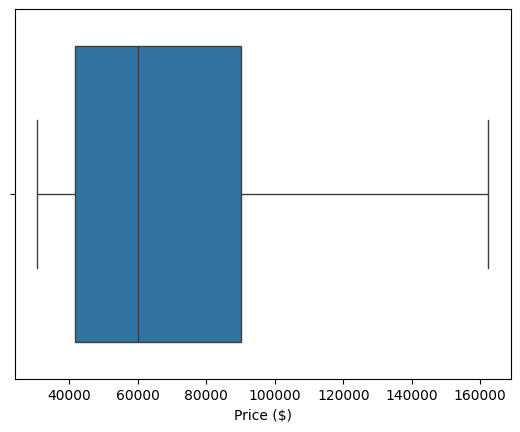

In [27]:
sns.boxplot(x="Price ($)", data=scraped_data)
plt.show()

### Organizing the data 
To be suitable for the integration 

In [28]:
# Divide the 'Name' column into 'Company' and 'Model' columns so we can merge them with our old dataset that contains Company name and Model name
scraped_data[['Year', 'Company', 'Model']] = scraped_data['Name'].str.extract(r'(\d{4})\s(.+?)\s(.+)')
scraped_data.drop(columns=["Name"], inplace=True)

# Tidy the data by reordering columns
scraped_data = scraped_data[['Company', 'Model', 'Mileage', 'Dealer_Name', 'Rating', 'Review Count', 'Price ($)']]

print(scraped_data.head())

# Save the cleaned and tidied data to a new CSV file
scraped_data.to_csv("../data/processed/cleaned_scraped_data.csv", index=False)


         Company                Model  Mileage  \
0            GMC   Sierra 2500 Denali    23249   
1            BMW    X5 PHEV xDrive45e    22255   
2        Ferrari     Portofino M Base     1959   
3        Ferrari         California T     7478   
4  Mercedes-Benz  EQS 580 Base 4MATIC     6558   

                                      Dealer_Name Rating  Review Count  \
0                           Mitch Smith Chevrolet    4.1           135   
1                                BMW of Las Vegas    4.8             2   
2                         Twin Cities Performance    n/a             0   
3  Ferrari Maserati Alfa Romeo of Fort Lauderdale    4.8             2   
4                 Mercedes-Benz of Salt Lake City    4.6           427   

   Price ($)  
0   68993.00  
1   47882.00  
2  162373.75  
3  159900.00  
4   75799.00  


In [29]:
scraped_data

,Company,Model,Mileage,Dealer_Name,Rating,Review Count,Price ($)
0,GMC,Sierra 2500 Denali,23249,Mitch Smith Chevrolet,4.1,135,68993.00
1,BMW,X5 PHEV xDrive45e,22255,BMW of Las Vegas,4.8,2,47882.00
2,Ferrari,Portofino M Base,1959,Twin Cities Performance,n/a,0,162373.75
3,Ferrari,California T,7478,Ferrari Maserati Alfa Romeo of Fort Lauderdale,4.8,2,159900.00
4,Mercedes-Benz,EQS 580 Base 4MATIC,6558,Mercedes-Benz of Salt Lake City,4.6,427,75799.00
...,...,...,...,...,...,...,...
226,Mercedes-Benz,AMG GT 53 AMG GT 53,4164,Isringhausen Imports,5.0,977,104900.00
227,Audi,S4 Prestige-CERTIFIED,8548,Audi McKinney,n/a,6,51991.00
228,Honda,Pilot 2WD EX-L 7 Passenger,10296,Yuma Honda,4.9,592,37998.00
229,Mercedes-Benz,AMG E 53 E 53 AMG,2435,Loeber Motors Mercedes-Benz,n/a,0,66998.00


# Integration

I'll use the Outer Join(his method retains all rows from both datasets and matches them based on the specified columns. It fills in missing values with NaN for unmatched rows.), to ensure that all records from both datasets are included in the merged dataset, preserving the maximum amount of data to use it answering our new question

In [30]:
# Read the cleaned scraped data and other dataset
scraped_data = pd.read_csv("../data/processed/cleaned_scraped_data.csv")
old_dataset = pd.read_csv("../data/processed/cleaned_data.csv")

merged_data = pd.merge(scraped_data, old_dataset, on=['Company', 'Model', 'Dealer_Name', 'Price ($)'], how='outer')


# Display the merged data
print(merged_data)


      Company     Model  Mileage         Dealer_Name  Rating  Review Count  \
0       Acura  ILX Base  12604.0  Johnson City Mazda     NaN           1.0   
1       Acura  ILX Base  12604.0  Johnson City Mazda     NaN           1.0   
2       Acura  ILX Base  12604.0  Johnson City Mazda     NaN           1.0   
3       Acura  ILX Base  12604.0  Johnson City Mazda     NaN           1.0   
4       Acura  ILX Base  12604.0  Johnson City Mazda     NaN           1.0   
...       ...       ...      ...                 ...     ...           ...   
23928   Volvo       V70      NaN  Tri-State Mack Inc     NaN           NaN   
23929   Volvo       V70      NaN  Tri-State Mack Inc     NaN           NaN   
23930   Volvo       V70      NaN           U-Haul CO     NaN           NaN   
23931   Volvo       V70      NaN           U-Haul CO     NaN           NaN   
23932   Volvo       V70      NaN           U-Haul CO     NaN           NaN   

       Price ($)        Car_id        Date Customer Name Gender

### Output the integrated data to csv file

In [31]:
merged_data.to_csv("../data/processed/merged_data.csv", index=False)

### Checking if there is any possible data loss as result of integration
We evaluated data loss by comparing the total number of records before and after the merge operation. Data loss percentage indicates the proportion of records that were not retained after the merge.


In [32]:
data_loss_percentage = ((len(scraped_data) + len(old_dataset)) - len(merged_data)) / (len(scraped_data) + len(old_dataset)) * 100
print(f"Data loss percentage: {data_loss_percentage}%")

Data loss percentage: 0.0%


#  The Additional Questions
regarding trends in the data sets. For example, (changes of specific  features over time, place, age groups, gender- groups, country, region, profit, losses,  ratings, etc.). Different visualization techniques should be used, with justification of the  chosen visualization method. 

# 1- Is there a relation between dealerships and specific companies
### Are there specific dealerships that consistently offer lower or higher prices compared to others for certain car companys?/ Are there specific dealerships that only offer/deal with specific car companys?

Goals: Identify dealerships that offer competitive prices or premium pricing for specific car models, helping customers make informed decisions and dealerships adjust their pricing strategies accordingly.

Hints:

Group the data by Dealer_Name and Model to calculate the average price for each combination of Dealer_Name and Model.
Visualize the average prices across different dealerships using a bar plot or box plot to compare pricing strategies.

C:\Users\HP\AppData\Local\Temp\ipykernel_15972\3083659279.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=average_prices, x='Dealer_Name', y='Price ($)', hue='Company', ci=None)


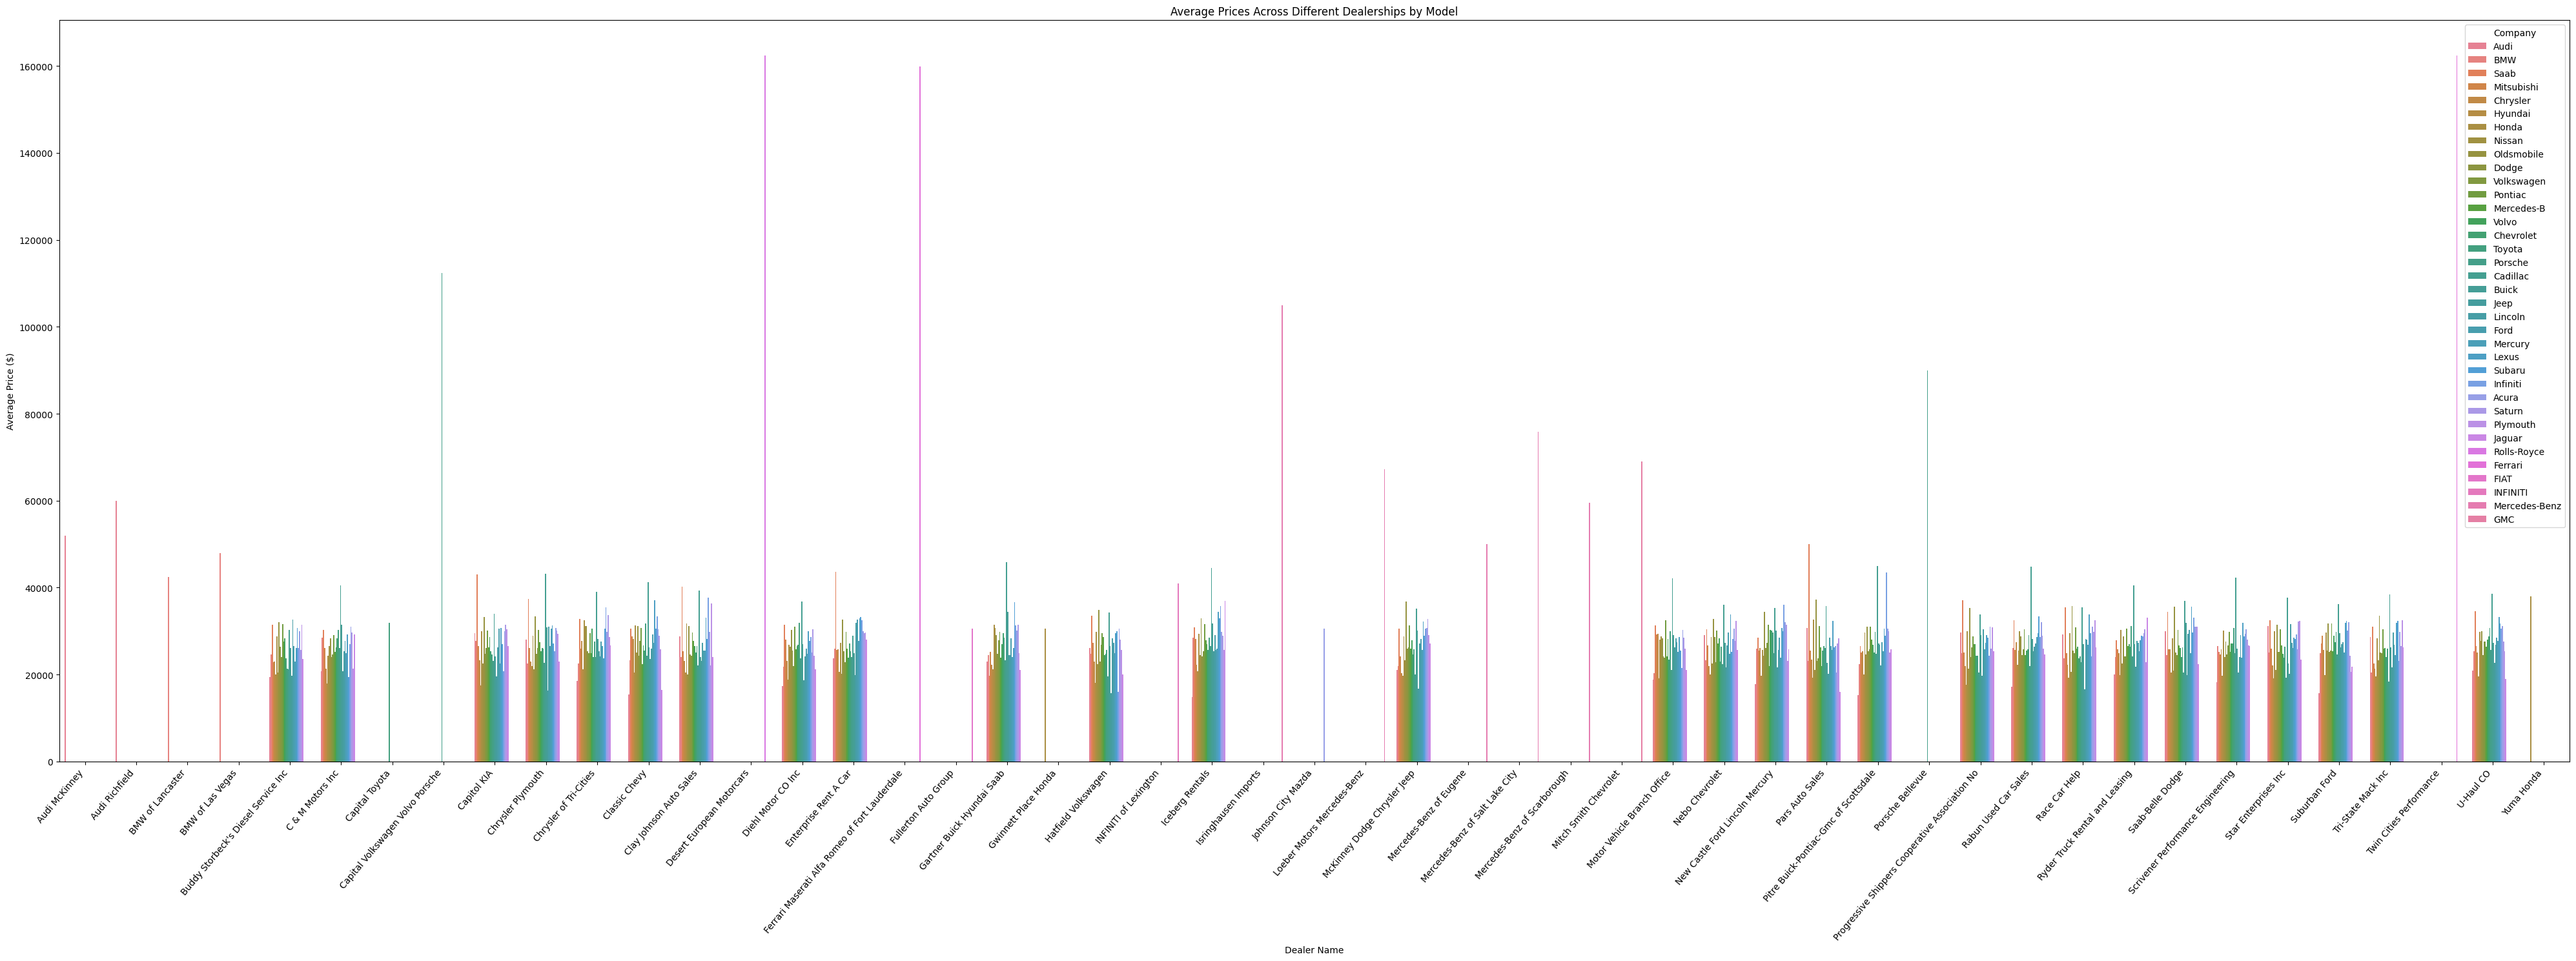

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your merged dataset is stored in a DataFrame called merged_df

# Group the data by Dealer_Name, Model, and Company to calculate the average price
average_prices = merged_data.groupby(['Dealer_Name', 'Model', 'Company'])['Price ($)'].mean().reset_index()

# Visualize the average prices across different dealerships using a bar plot
plt.figure(figsize=(40, 15))
sns.barplot(data=average_prices, x='Dealer_Name', y='Price ($)', hue='Company', ci=None)
plt.title('Average Prices Across Different Dealerships by Model')
plt.xlabel('Dealer Name')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=50, ha='right')
plt.tight_layout()
plt.legend(title='Company')
plt.show()


<font color = red> Note that we set a small size for lable values so it can be readable if we zoomed in the plot </font>

### findings
Based on the analysis, it appears that there are indeed specific dealerships that have exclusive partnerships or preferences for certain car companies. For example, Aristocrat Motors exclusively works with Porsche, indicating a strong relationship between this dealership and the Porsche brand. Similarly, it's observed that Mercedes-Benz tends to have partnerships with dealerships that primarily deal with Mercedes-Benz cars, suggesting a close collaboration between the company and these dealerships.

Additionally, some dealerships offer relatively lower prices compared to others for specific car companies. For instance, Classic Chevrolet offers slightly lower prices for Mitsubishi cars compared to other dealerships, indicating a potentially competitive pricing strategy in relation to Mitsubishi vehicles. Conversely, Capital Kia appears to offer higher prices for Kia vehicles compared to other dealerships, suggesting that this dealership may position itself in the market with a premium pricing strategy for Kia cars.

These findings highlight the importance of understanding the relationships between dealerships and specific car companies, as well as the pricing strategies employed by different dealerships. This information can be valuable for both customers, who can make more informed decisions based on pricing and brand preferences, and dealerships, which can adjust their strategies to stay competitive in the market.


# 2- What is the dealer name of the highest dealer rating?
## 	Goals: The goal of the question to know the (4.5 to 5) rating dealers.
## 	Hint: Collect the data from rating where the data is => than 4.5.
# What is the name and price of the lower dealers rating?
## 	Goals: The goal of the question to know the (0 to 2) rating dealers.
## 	Hint: Collect the data from rating where the data is =< than 2


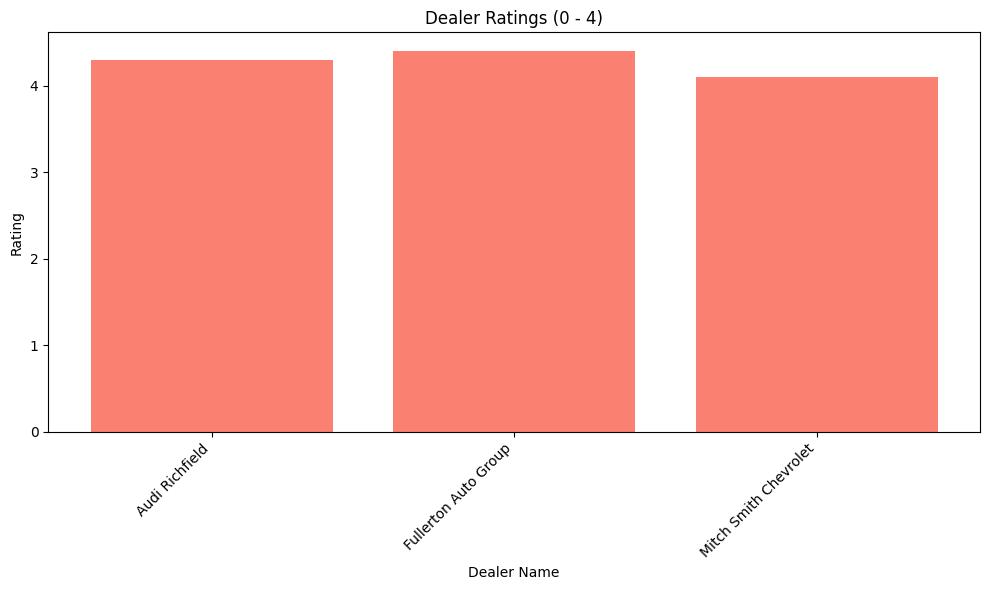

Dealer with the lowest rating in the range 0 to 4: Mitch Smith Chevrolet - Rating: 4.1


In [35]:
lowest_rated_df = merged_data[(merged_data['Rating'] >= 0) & (merged_data['Rating'] <= 4.5)]
if not lowest_rated_df.empty:
    lowest_rated_dealer = lowest_rated_df.loc[lowest_rated_df['Rating'].idxmin()]

    plt.figure(figsize=(10, 6))
    plt.bar(lowest_rated_df['Dealer_Name'], lowest_rated_df['Rating'], color='salmon')
    plt.xlabel('Dealer Name')
    plt.ylabel('Rating')
    plt.title('Dealer Ratings (0 - 4)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print("Dealer with the lowest rating in the range 0 to 4:", lowest_rated_dealer['Dealer_Name'], "- Rating:", lowest_rated_dealer['Rating'])
else:
    print("There are no dealers with ratings between 0 and 4.")


## to find the lowest dealer rating who is ( Kia Delray = 0.13538150581944733) 

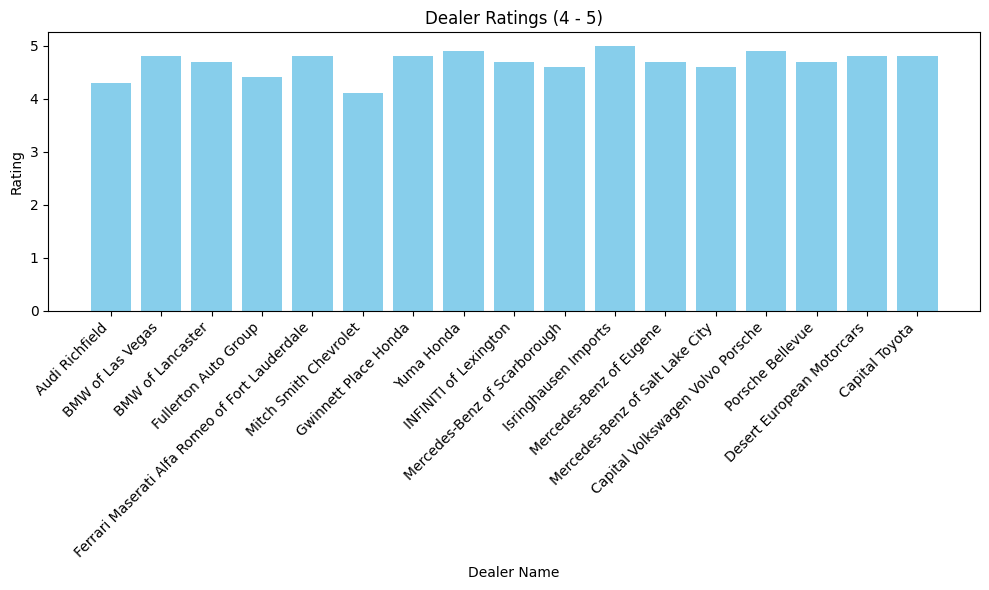

Dealer with the highest rating in the range 4 to 5: Isringhausen Imports - Rating: 5.0


In [36]:
filtered_df = merged_data[(merged_data['Rating'] >= 4) & (merged_data['Rating'] <= 5)]

highest_rated_dealer = filtered_df.loc[filtered_df['Rating'].idxmax()]
plt.figure(figsize=(10, 6))
plt.bar(filtered_df['Dealer_Name'], filtered_df['Rating'], color='skyblue')
plt.xlabel('Dealer Name')
plt.ylabel('Rating')
plt.title('Dealer Ratings (4 - 5)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Dealer with the highest rating in the range 4 to 5:", highest_rated_dealer['Dealer_Name'], "- Rating:", highest_rated_dealer['Rating'])


## to find the highest dealer rating who is (Isringhausen = 4.9) 

### -------------------------------------------------------------------------------------------------------------------------------------------------------

# 3- What is the average price of cars that have less than 10,000 mileage? 
## 	Goals: to know the average price of cars that been driven less than 10,000 miles 
## 	Hint: collect data from mileage where is less than 10,000 and get the main () of the prices 


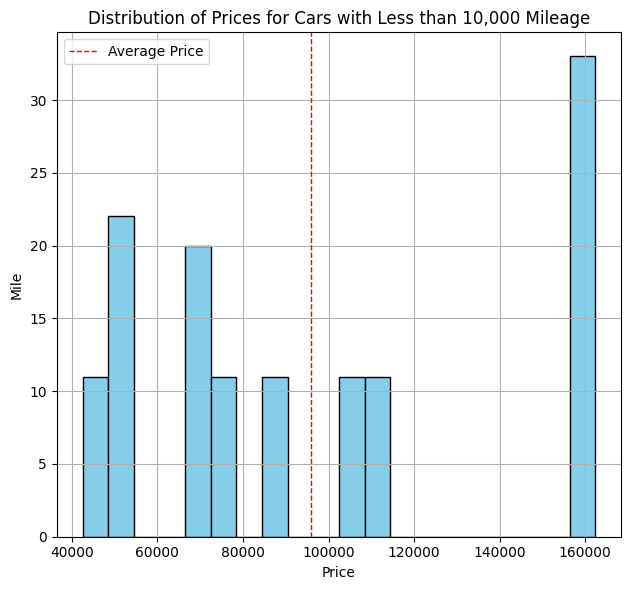

Average price of cars with less than 10,000 mileage: 95991.25


In [37]:


filtered_carsM = merged_data[merged_data['Mileage'] < 10000]

average_price = filtered_carsM['Price ($)'].mean()

plt.figure(figsize=(18, 6))


plt.subplot(1, 3, 1)
plt.hist(filtered_carsM['Price ($)'], bins=20, color='skyblue', edgecolor='black')
plt.axvline(average_price, color='red', linestyle='dashed', linewidth=1, label='Average Price')
plt.xlabel('Price')
plt.ylabel('Mile')
plt.title('Distribution of Prices for Cars with Less than 10,000 Mileage')
plt.legend()
plt.grid(True)





for i, txt in enumerate(filtered_carsM['Company']):
    plt.annotate(txt, (filtered_carsM['Mileage'].iloc[i], filtered_carsM['Price ($)'].iloc[i]))

plt.grid(True)

plt.tight_layout()
plt.show()

print("Average price of cars with less than 10,000 mileage:", average_price)


 ### We know from this grapgh the Average prices of cars the been driven less than 10,000  that is =       92674.86746987952

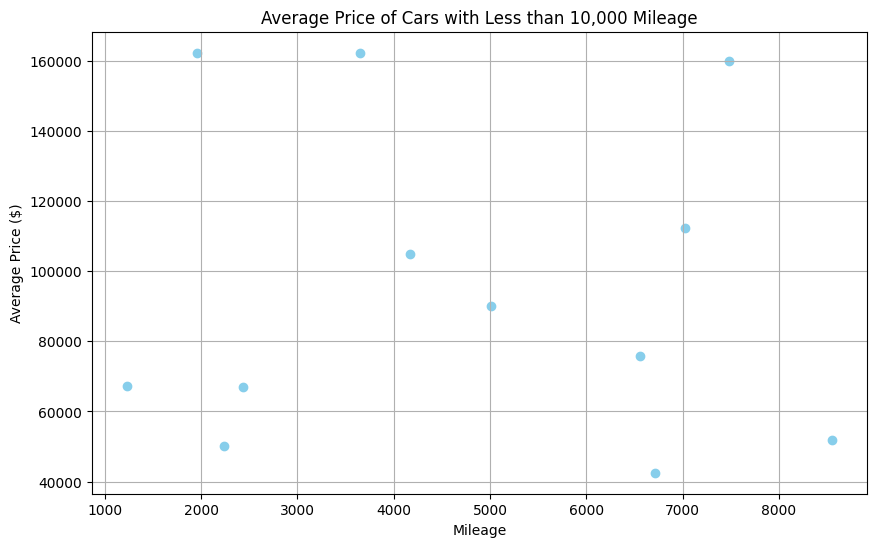

In [38]:



filtered_carsM = merged_data[merged_data['Mileage'] < 10000]

average_prices_by_mileage = filtered_carsM.groupby('Mileage')['Price ($)'].mean().reset_index()


plt.figure(figsize=(10, 6))
plt.scatter(average_prices_by_mileage['Mileage'], average_prices_by_mileage['Price ($)'], color='skyblue')
plt.xlabel('Mileage')
plt.ylabel('Average Price ($)')
plt.title('Average Price of Cars with Less than 10,000 Mileage')
plt.grid(True)
plt.show()



### In this plot the range of the cars the mileage and it prices like the car that been driven from 0 to 2000 mile the price of them if above 10,000 and the the average vars price that been driven between 2000 and 6000 is less than 80,000 and the cars between 6000 t0 10000 the car price reach 18,0000 



C:\Users\HP\AppData\Local\Temp\ipykernel_15972\1018852626.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Company', y='Mileage', data=filtered_carsM, jitter=True, palette='Set2')


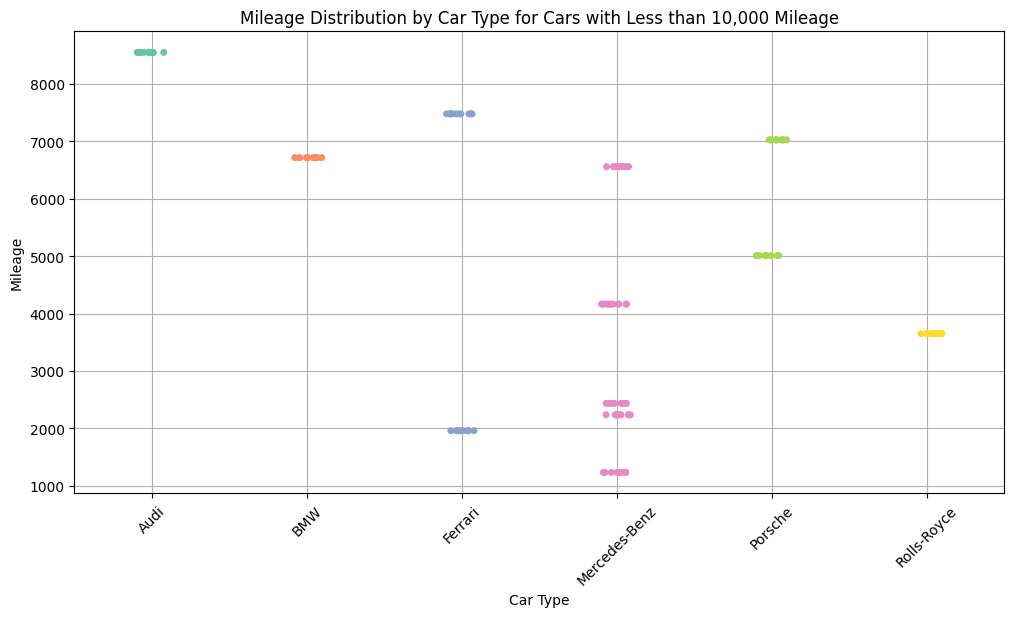

In [39]:



filtered_carsM = merged_data[merged_data['Mileage'] < 10000]

plt.figure(figsize=(12, 6))
sns.stripplot(x='Company', y='Mileage', data=filtered_carsM, jitter=True, palette='Set2')
plt.xlabel('Car Type')
plt.ylabel('Mileage')
plt.title('Mileage Distribution by Car Type for Cars with Less than 10,000 Mileage')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


   ### In this graph we know  each car model  and the average of miles that it been driven like (kia =4000) And      (mercedes benz = 1,0000 ) (Ferrari = 6000) (porsche => 2000 ) (Hyundai 3000 and 7000) (Audi = 5000)

Correlation coefficient between Price and Rating: 0.2752464203762043


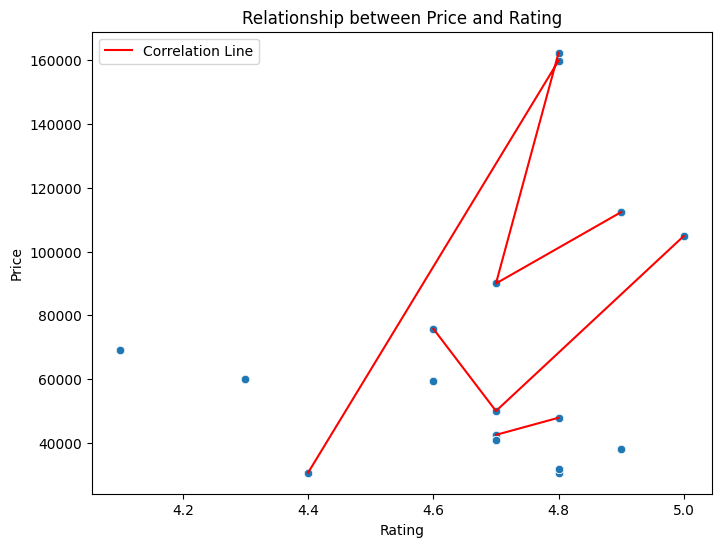

In [40]:
correlation = merged_data['Price ($)'].corr(merged_data['Rating'])
print("Correlation coefficient between Price and Rating:", correlation)


model = np.polyfit(merged_data['Price ($)'], merged_data['Price ($)'], 1)
predicted = np.polyval(model, merged_data['Price ($)'])


plt.figure(figsize=(8, 6))
sns.scatterplot(x='Rating', y='Price ($)', data=merged_data)
plt.plot(merged_data['Rating'], predicted, color='red', label='Correlation Line')
plt.title('Relationship between Price and Rating')
plt.xlabel('Rating')
plt.ylabel('Price')
plt.legend()
plt.show()

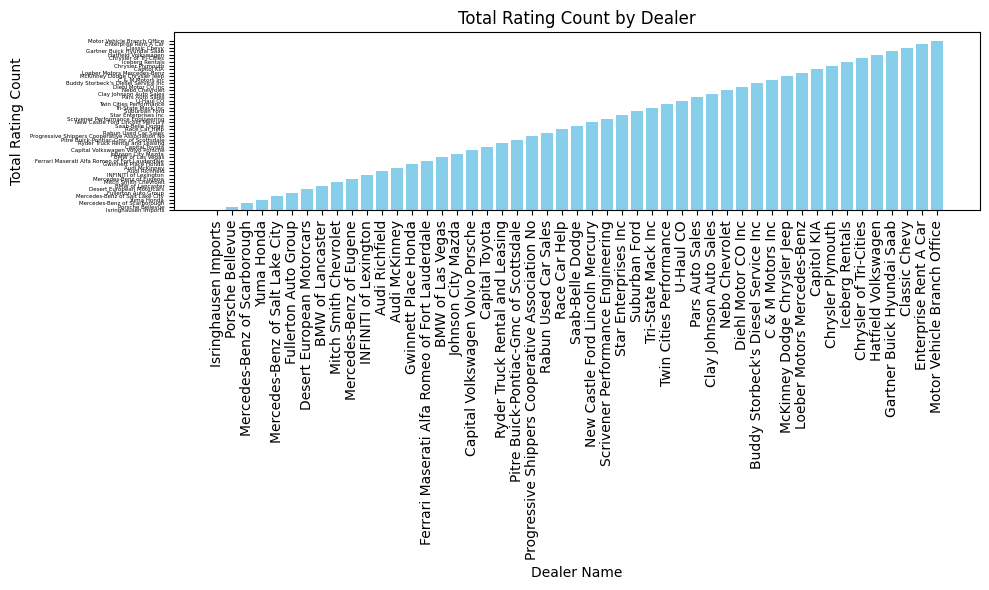

In [44]:
total_rating_count_by_dealer = merged_data.groupby('Dealer_Name')['Review Count'].sum().reset_index()

total_rating_count_by_dealer.sort_values(by='Review Count', ascending=False, inplace=True)


plt.figure(figsize=(10, 6))
plt.bar(total_rating_count_by_dealer['Dealer_Name'], total_rating_count_by_dealer['Dealer_Name'], color='skyblue')
plt.title('Total Rating Count by Dealer')
plt.xlabel('Dealer Name')
plt.ylabel('Total Rating Count')
plt.xticks(rotation=90) 

#Set the font size of y-axis ticks for more readablity 
plt.tick_params(axis='y', labelsize=4) #you can zoom in the expand image to read the values

plt.tight_layout()
plt.show()

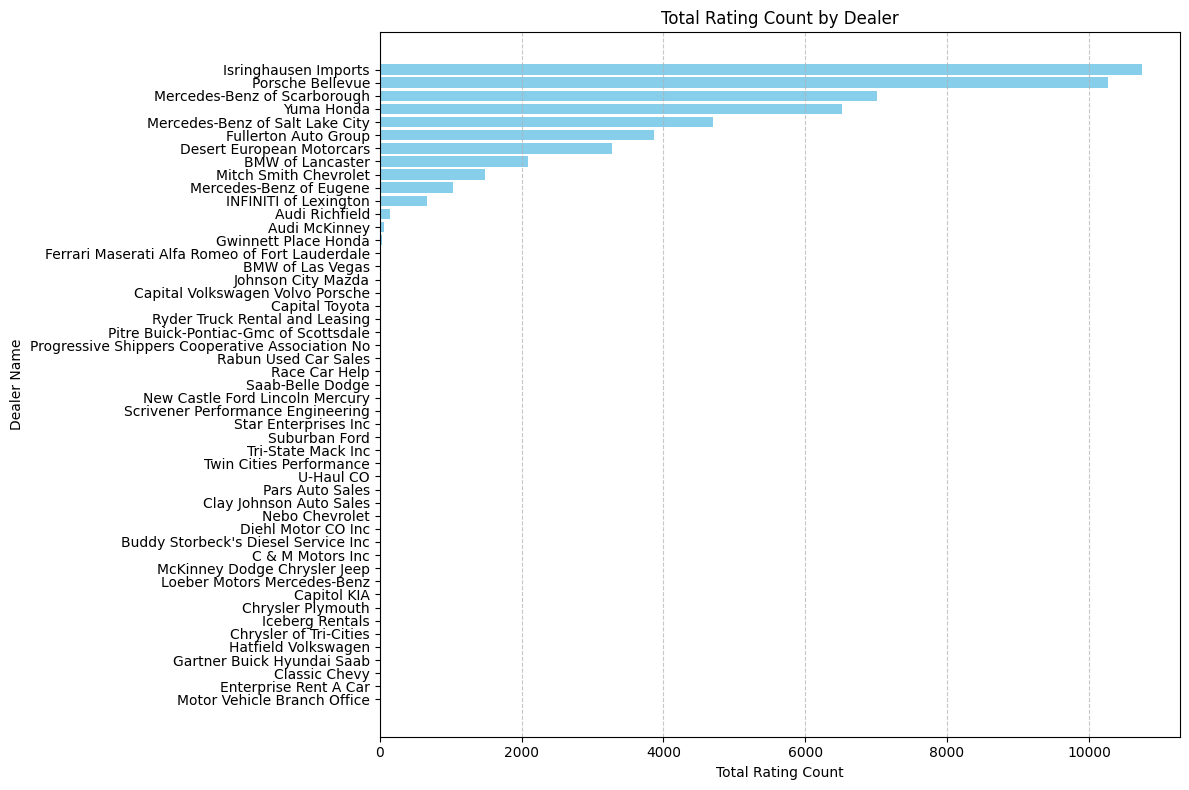

In [42]:

total_rating_count_by_dealer = merged_data.groupby('Dealer_Name')['Review Count'].sum().reset_index()

total_rating_count_by_dealer.sort_values(by='Review Count', ascending=False, inplace=True)


plt.figure(figsize=(12, 8))  
plt.barh(total_rating_count_by_dealer['Dealer_Name'], total_rating_count_by_dealer['Review Count'], color='skyblue')  # Use horizontal bar plot
plt.title('Total Rating Count by Dealer')
plt.xlabel('Total Rating Count')
plt.ylabel('Dealer Name')
plt.gca().invert_yaxis()  
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The most reviewed Dealer              Dealer_Name  Review Count
23  Isringhausen Imports       10747.0


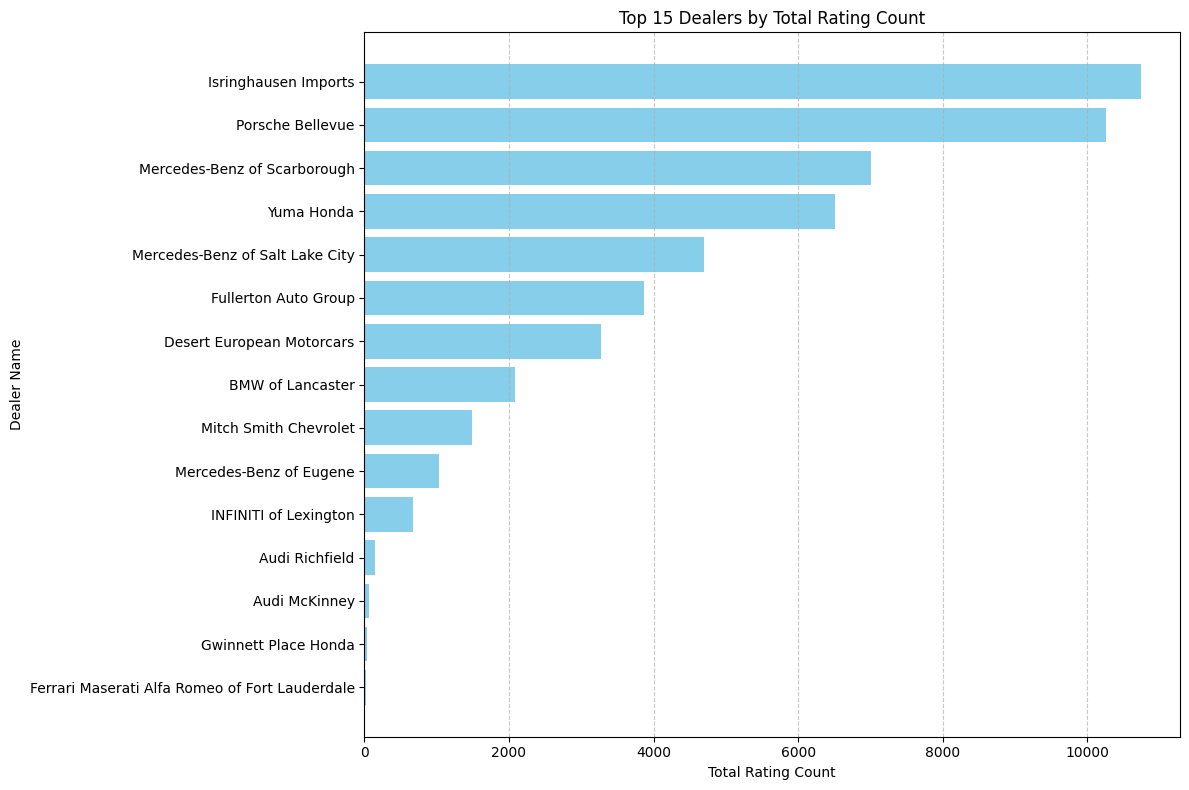

In [45]:
total_rating_count_by_dealer = merged_data.groupby('Dealer_Name')['Review Count'].sum().reset_index()

total_rating_count_by_dealer.sort_values(by='Review Count', ascending=False, inplace=True)

top_15_dealers = total_rating_count_by_dealer.head(15)

print("The most reviewed Dealer", top_15_dealers.head(1))

plt.figure(figsize=(12, 8)) 
plt.barh(top_15_dealers['Dealer_Name'], top_15_dealers['Review Count'], color='skyblue')  
plt.title('Top 15 Dealers by Total Rating Count')
plt.xlabel('Total Rating Count')
plt.ylabel('Dealer Name')
plt.gca().invert_yaxis()  
plt.grid(axis='x', linestyle='--', alpha=0.7)  
plt.tight_layout()
plt.show()

## Findings

### -Based on the analysis, it appears that we can know the most selling dealers in the market through the review count and know which dealers can be trusted and suggest them to customers.

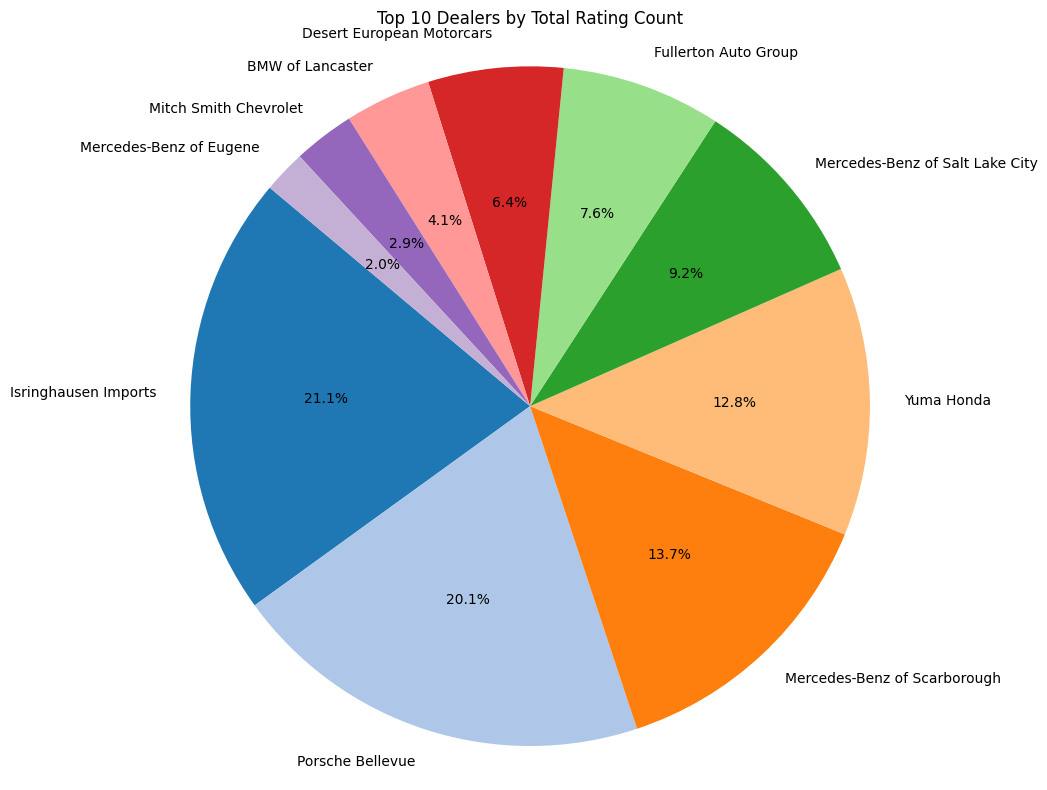

In [46]:
total_rating_count_by_dealer = merged_data.groupby('Dealer_Name')['Review Count'].sum().reset_index()


total_rating_count_by_dealer.sort_values(by='Review Count', ascending=False, inplace=True)

top_15_dealers = total_rating_count_by_dealer.head(10)
plt.figure(figsize=(10, 8))
plt.pie(top_15_dealers['Review Count'], labels=top_15_dealers['Dealer_Name'], autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title('Top 10 Dealers by Total Rating Count')
plt.axis('equal') 
plt.tight_layout()
plt.show()


### -This analysis shows the percentage for each Dealer to get reviewed from the top 10 most reviewed Dealers

# Extra Questions:

## 1- How does the price of a car model vary with its mileage?

Goals: Explore the relationship between car mileage and pricing to understand the depreciation rate and adjust pricing strategies accordingly.

Hints:

Group the data by car models.
Calculate the average price for different mileage ranges within each car model.
Visualize the relationship between mileage and price using a scatter plot or line plot.

ustification of chosen visualization method:

A scatter plot is an appropriate choice for visualizing the relationship between mileage and price for car models because it allows us to observe individual data points (car models) and see how their average prices vary with average mileage. Scatter plots are effective for showing correlations between two continuous variables, making it easy to identify any patterns or trends in the data. 


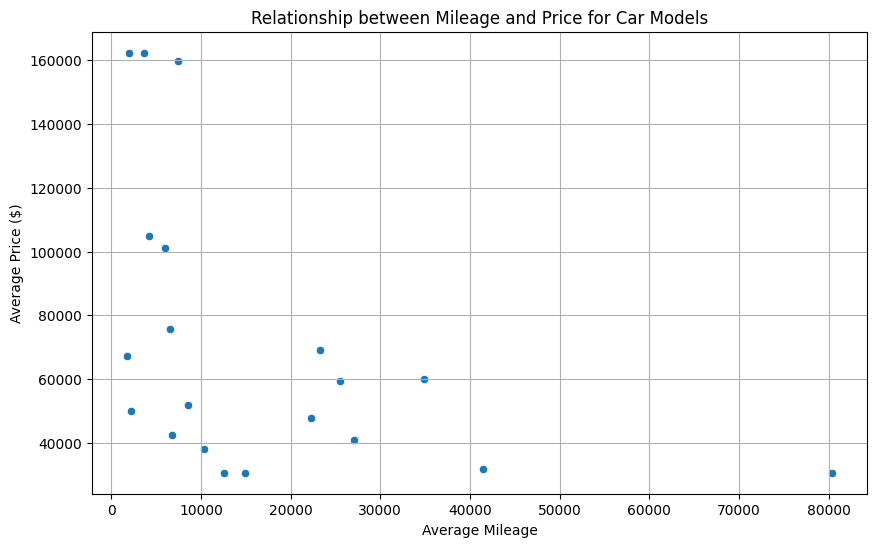

,Model,Average Price ($),Average Mileage
0,3-Sep,34606.497041,NaN
1,3000GT,22297.043624,NaN
2,300M,21394.888889,NaN
3,323i,17355.634615,NaN
4,328i,26210.584158,NaN
...,...,...,...
169,Windstar,23598.508475,NaN
170,Wrangler,20071.293210,NaN
171,X5 PHEV xDrive45e,47882.000000,22255.0
172,Xterra,18901.076087,NaN


In [47]:

# Group the data by car models
grouped_data = merged_data.groupby('Model')

# Initialize lists to store average price and mileage for each model
model_names = []
average_prices = []
average_mileages = []

# Calculate the average price and mileage for each model
for model, group_data in grouped_data:
    average_price = group_data['Price ($)'].mean()
    average_mileage = group_data['Mileage'].mean()
    model_names.append(model)
    average_prices.append(average_price)
    average_mileages.append(average_mileage)

# Create a DataFrame for visualization
price_mileage_df = pd.DataFrame({'Model': model_names, 'Average Price ($)': average_prices, 'Average Mileage': average_mileages})

# Visualize the relationship between mileage and price using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=price_mileage_df, x='Average Mileage', y='Average Price ($)')
plt.title('Relationship between Mileage and Price for Car Models')
plt.xlabel('Average Mileage')
plt.ylabel('Average Price ($)')
plt.grid(True)
plt.show()
price_mileage_df


#### Findings
Based on the analysis of the relationship between car mileage and pricing:

The scatter plot illustrates that there is a negative correlation between mileage and price for car models. As the average mileage increases, the average price tends to decrease. This indicates that higher mileage tends to lower the price of car models.
This observation suggests that mileage is an important factor influencing the pricing of car models. Customers may perceive higher mileage as indicative of increased wear and tear on the vehicle, leading to lower prices.
However, it's essential to note that other factors such as model year, condition, and market demand also play significant roles in determining car prices.

# 2- How do customer ratings and reviews impact car sales and dealership performance?
Goals: Analyze the relationship between customer ratings, reviews, and sales performance of dealerships.

Hints:
Explore the correlation between customer ratings/reviews and sales volume or revenue.
Group the data by dealerships and analyze the distribution of ratings and reviews.

Visualization:
Scatter plots to visualize the relationship between ratings/reviews and sales performance.
Bar charts or histograms to show the distribution of ratings and reviews among dealerships.

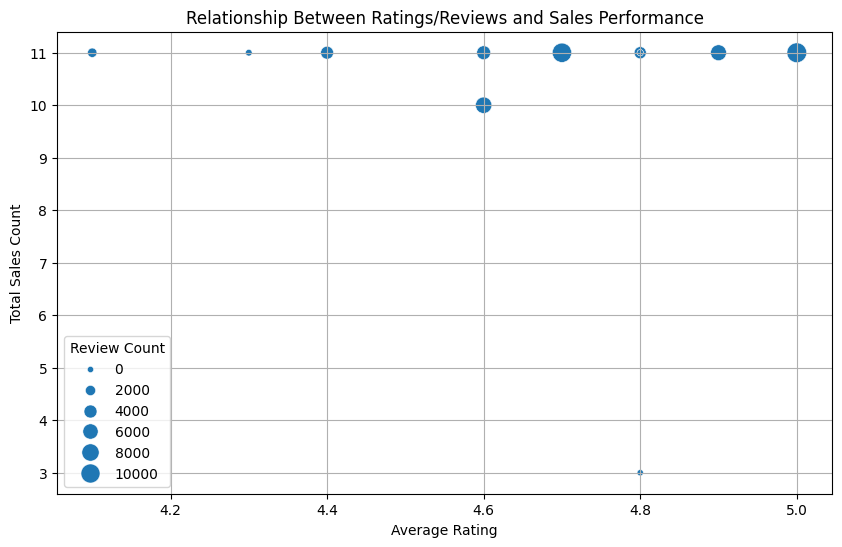

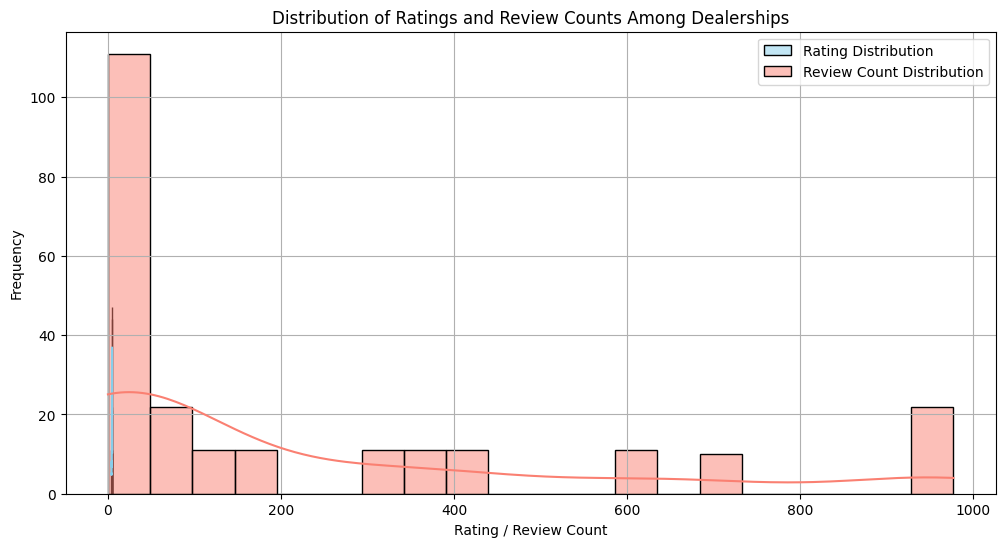

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset containing dealership information
# Replace 'dealership_data.csv' with the actual filename/path
dealership_data = pd.read_csv('../data/processed/merged_data.csv')

# Count the number of sales for each dealership
dealership_sales_count = dealership_data['Dealer_Name'].value_counts().reset_index()
dealership_sales_count.columns = ['Dealer_Name', 'Sales_Count']

# Group the data by dealership and calculate aggregate metrics
dealership_agg = dealership_data.groupby('Dealer_Name').agg({
    'Rating': 'mean',              # Average rating
    'Review Count': 'sum',         # Total review count
}).reset_index()

# Merge sales count data with aggregate data
dealership_agg = pd.merge(dealership_agg, dealership_sales_count, on='Dealer_Name', how='left')

# Visualize the relationship between ratings/reviews and sales performance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dealership_agg, x='Rating', y='Sales_Count', size='Review Count', sizes=(20, 200))
plt.title('Relationship Between Ratings/Reviews and Sales Performance')
plt.xlabel('Average Rating')
plt.ylabel('Total Sales Count')
plt.grid(True)
plt.show()

# Visualize the distribution of ratings and reviews among dealerships
plt.figure(figsize=(12, 6))
sns.histplot(data=dealership_data, x='Rating', bins=10, kde=True, color='skyblue', label='Rating Distribution')
sns.histplot(data=dealership_data, x='Review Count', bins=20, kde=True, color='salmon', label='Review Count Distribution')
plt.title('Distribution of Ratings and Review Counts Among Dealerships')
plt.xlabel('Rating / Review Count')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()


#### Findings
The scatter plot visualizes the relationship between average ratings, total review counts, and sales performance of dealerships. It indicates that there is no clear linear correlation between average rating and total sales count. However, it seems that dealerships with higher review counts tend to have higher sales counts, suggesting a potential positive relationship between the two variables.
The distribution histograms show the spread of ratings and review counts among dealerships. Most dealerships have ratings concentrated around certain values, with some variability in review counts. This suggests that while there may be outliers with extremely high or low ratings, most dealerships maintain relatively consistent rating distributions.
Overall, while customer ratings and reviews may influence sales performance to some extent, other factors such as marketing strategies, product offerings, and customer service also play crucial roles in dealership success.

# Hypothesis 1:

I propose that there's a connection between the ratings given to car dealerships and the prices they offer for their cars. Specifically, I suspect that higher-rated dealerships tend to offer cars at higher prices, while lower-rated ones might offer lower-priced vehicles.

### Hypothesis Testing

To test this hypothesis, we will perform a correlation analysis between dealership ratings and the average price of cars they offer. We'll use Pearson's correlation coefficient to measure the strength and direction of the relationship between these variables.

There is a significant correlation between dealership ratings and the average price of cars they offer, we'll perform Pearson's correlation coefficient analysis. This will help us understand the strength and direction of the relationship between these variables.

Let's start by calculating the correlation coefficient and determining its statistical significance.

In [52]:
# Check for missing or invalid values in the 'Rating' and 'Price ($)' columns
missing_values = merged_data[['Rating', 'Price ($)']].isnull().sum()
# Drop rows with missing or invalid values
merged_data_cleaned = merged_data.dropna(subset=['Rating', 'Price ($)'])

# Calculate Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(merged_data_cleaned['Rating'], merged_data_cleaned['Price ($)'])

# Print the correlation coefficient and p-value
print("Correlation Coefficient:", correlation_coefficient)
print("P-value:", p_value)


Correlation Coefficient: 0.27524642037620445
P-value: 0.00020044243894533462


#### Interpretation

The correlation coefficient measures the strength and direction of the relationship between dealership ratings and the average price of cars they offer. If the correlation coefficient is close to 1, it indicates a strong positive correlation, while a value close to -1 indicates a strong negative correlation. A correlation coefficient close to 0 suggests no linear relationship between the variables.

The p-value indicates the statistical significance of the correlation coefficient. A p-value less than 0.05 generally suggests that the correlation is statistically significant.

Then we can interpret the results based on the correlation coefficient and p-value.

# Hypothesis 2: 

 My suspicion is that there's a relationship between the mileage of a car and its price. I believe that cars with lower mileage are likely to have higher prices compared to those with higher mileage.


Hypothesis Testing
To test this hypothesis, we'll examine the relationship between the mileage of cars and their average prices. We'll analyze whether there's a significant correlation between these two variables and whether the correlation supports our hypothesis. There is a relationship between the mileage of a car and its average price, with lower mileage cars having higher average prices, we'll perform correlation analysis between the mileage of cars and their average prices.



In [50]:
import numpy as np
from scipy.stats import pearsonr

# Remove rows with missing or infinite values
cleaned_data = merged_data.dropna(subset=['Mileage', 'Price ($)'], axis=0)
cleaned_data = cleaned_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['Mileage', 'Price ($)'], how="all")

# Calculate Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(cleaned_data['Mileage'], cleaned_data['Price ($)'])

# Print the correlation coefficient and p-value
print("Correlation Coefficient:", correlation_coefficient)
print("p-value:", p_value)


Correlation Coefficient: -0.4246960442755972
p-value: 1.5658462925664576e-11


C:\Users\HP\AppData\Local\Temp\ipykernel_15972\467612439.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_data = cleaned_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['Mileage', 'Price ($)'], how="all")


Interpretation
The correlation coefficient will indicate the strength and direction of the relationship between car mileage and average price. If the correlation coefficient is positive, it suggests a positive relationship, meaning as mileage increases, the average price also tends to increase. If the correlation coefficient is negative, it indicates a negative relationship, suggesting that as mileage increases, the average price decreases. A correlation coefficient close to 0 suggests no linear relationship between the variables.

The p-value will indicate the statistical significance of the correlation coefficient. A p-value less than 0.05 generally suggests that the correlation is statistically significant.
Let's interpret the results based on the correlation coefficient and p-value.
